In [3]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from ipywidgets import Dropdown, Output, HBox, VBox
from IPython.display import display, clear_output
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
np.random.seed(42)

STEPS:
Load and split — separate data into train and test sets before touching the model
Fit — show the algorithm the training examples; it adjusts internal parameters to minimize prediction error
Predict — apply the trained model to the held-out test set
Evaluate — measure how well predictions match the true labels using a metric suited to your problem type.

In [6]:
df = pd.read_csv("./student_scaled.csv")

In [ ]:
#for our first supervised learning model, we used the following features. 
features1 = [
    "studytime",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
]

X_features1 = df[features1].copy()

X_features1.head()

,studytime,freetime,goout,Dalc,Walc,health,absences
0,-0.042286,-0.236010,0.801479,-0.540699,-1.003789,-0.399289,0.036424
1,-0.042286,-0.236010,-0.097908,-0.540699,-1.003789,-0.399289,-0.213796
2,-0.042286,-0.236010,-0.997295,0.583385,0.551100,-0.399289,0.536865
3,1.150779,-1.238419,-0.997295,-0.540699,-1.003789,1.041070,-0.464016
4,-0.042286,-0.236010,-0.997295,-0.540699,-0.226345,1.041070,-0.213796


In [ ]:
#defining our independent and depedendent variables
#for the dependent varibale, we seperated the G3 column 
#(which is the final grade for students) into 4 categories, 
#that correspond with failure, low performance, high perfomance, and exceptional 
#performance

X1 = df[features1]
Y1 = pd.cut(
    df["G3"],
    bins=[-1, 9, 13, 17, 20],
    labels=[0, 1, 2, 3]
).astype(int)

In [ ]:
#assigning our independent and dependent variables to training and test variables.
#leaving 20% of our data out to be see how well model performs on unseen data 

from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1,
    Y1,
    test_size=0.2,
    random_state=42
)

In [99]:
#importing logistic regression package
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)

In [101]:
#fiting our training date to the model
model1.fit(X_train1, y_train1)
y_pred1 = model1.predict(X_test1)

In [102]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test1, y_pred1)

print(cm1)

[[11 14  1  0]
 [ 2 31  0  0]
 [ 3 13  0  0]
 [ 2  2  0  0]]


In [103]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(y_test1, y_pred1)

print(accuracy1)

0.5316455696202531


In [ ]:
#to display the classification predictions. The model is able to identify
#students with lower grades, and unable to identify any of the higher performing student
#We noticed that there is less data to be able to train with for higher performaing students, 
#which likely impacted the models ability to predict correctly for these groups.

from sklearn.metrics import classification_report

print(classification_report(y_test1, y_pred1))

              precision    recall  f1-score   support

           0       0.61      0.42      0.50        26
           1       0.52      0.94      0.67        33
           2       0.00      0.00      0.00        16
           3       0.00      0.00      0.00         4

    accuracy                           0.53        79
   macro avg       0.28      0.34      0.29        79
weighted avg       0.42      0.53      0.44        79



/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [ ]:
#LINEAR REGRESSION MODEL

In [8]:
#assigning our features to be used in our linear regression model.
features2 = [
    "studytime",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "failures",
]

In [9]:
#assigning our features to be independent variables, and G3 (final grades),
#to be our y value

X2 = df[features2]
Y2 = df["G3"]

In [10]:
#assigning our variable to be used for testing or training our model. 
#Reserving 20% of our data to be tested after our model is created.

from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    Y2,
    test_size=0.2,
    random_state=42
)

In [11]:
#importing linear regression package,
#fitting our training data to the linear regression model 
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()

model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

In [12]:
#determing the r2 score to see how well the X values predict the y values 

from sklearn.metrics import r2_score

r2 = r2_score(y_test2, y_pred2)

print(r2)

0.080408375527667


In [13]:
coefficients = pd.DataFrame({
    "Feature": X2.columns,
    "Coefficient": model2.coef_
})

print(coefficients)

     Feature  Coefficient
0  studytime     0.469821
1   freetime     0.323824
2      goout    -0.426090
3       Dalc    -0.054418
4       Walc     0.202007
5     health    -0.200687
6   absences     0.326391
7   failures    -1.664250


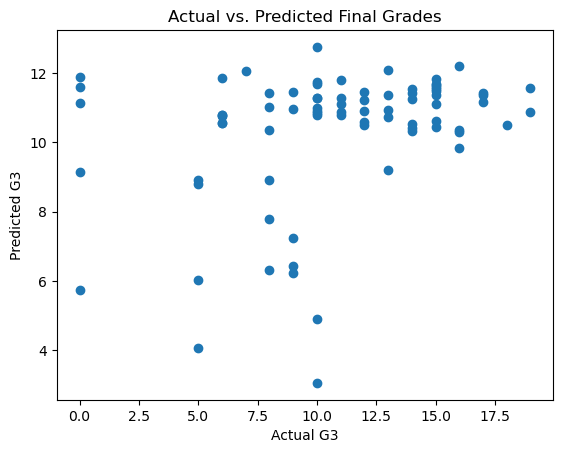

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test2, y_pred2)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs. Predicted Final Grades")

plt.show()

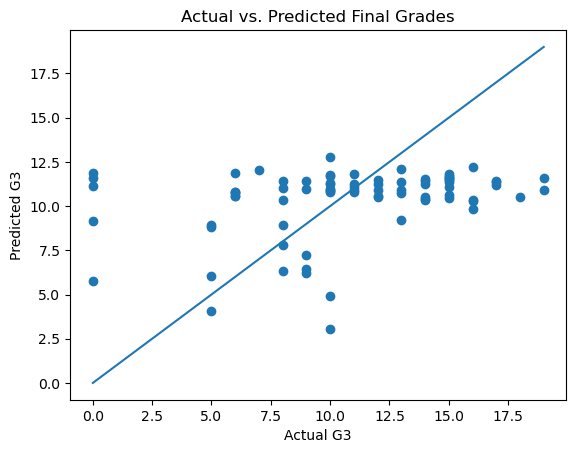

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test2, y_pred2)

# Perfect prediction line
plt.plot(
    [y_test2.min(), y_test2.max()],
    [y_test2.min(), y_test2.max()]
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs. Predicted Final Grades")

plt.show()

Model 3 - Also Linear Regression

In [111]:
#assigning grades from first and second semesters as features
#goal is to determine the correlation between these scores and the final score

features3 = ["G1", "G2"]

X3 = df[features3]
Y3 = df["G3"]

In [113]:
#training and testing our variables
from sklearn.model_selection import train_test_split

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3,
    Y3,
    test_size=0.2,
    random_state=42
)

In [114]:
#fitting our data to linear regression model

model3 = LinearRegression()

model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

In [ ]:
#identifying our r2 value - how well our predictions match the actual values. Math G1 and G3 do a prery good job
#of predicting G3, as indicated by the R2

r3 = r2_score(y_test3, y_pred3)

print(r3)

0.7945936216805896


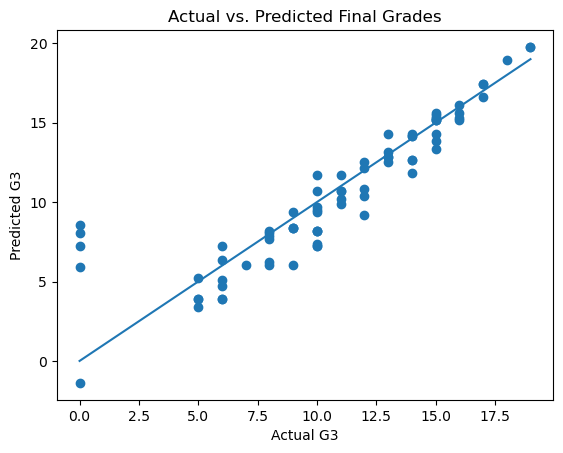

In [ ]:
#displaying visuals to better undertand the relationship between the
#prediction and actual values

plt.scatter(y_test3, y_pred3)

# Perfect prediction line
plt.plot(
    [y_test3.min(), y_test3.max()],
    [y_test3.min(), y_test3.max()]
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs. Predicted Final Grades")

plt.show()

LINEAR REG - multiple features, prediciting grade band withing G3

In [ ]:
#creating features for our supervised learning logistic regression model
#
features2 = [
    "studytime",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
]

In [16]:
X2 = df[features2]

Y2 = pd.cut(
    df["G3"],
    bins=[-1, 9, 13, 17, 20],
    labels=["failing", "low", "high", "exceptional"]
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X2,
    Y2,
    test_size=0.2,
    random_state=42,
)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.35443037974683544


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

 exceptional       0.00      0.00      0.00         3
     failing       0.50      0.33      0.40        27
        high       0.00      0.00      0.00        23
         low       0.33      0.73      0.46        26

    accuracy                           0.35        79
   macro avg       0.21      0.27      0.21        79
weighted avg       0.28      0.35      0.29        79



/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 0  0  0  3]
 [ 0  9  2 16]
 [ 0  4  0 19]
 [ 0  5  2 19]]


Logistic Regression - predicing famsup is True of False, given the features below

In [120]:
##use supervised learning model to determine whether selected features can predict whether student has family support (famsup)
Y = df['famsup_yes']

In [122]:
#encoding the values in column famsup from yes or no to 1(yes) or 0(no) - EDIT
Y = df['famsup_yes']

In [123]:
#identifying the X values/independent features that we think will impact the Y - whether or not student has family support
features = ["studytime", 
            "Dalc",  
            "absences"
            ]

X = df[features]
Y = df['famsup_yes']

In [124]:
#assinging our independent and dependent variables to training and test variables.
#leaving 20% of our data out to be see how well model performs on unseen data 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [126]:
print(Y.head())

0    False
1     True
2    False
3     True
4     True
Name: famsup_yes, dtype: bool


In [127]:
#importing logistic regression packagte
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [128]:
#fiting our training date to the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [129]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.6075949367088608


In [130]:
#displaying how well our classification model did.
#it was able to identify when students were classified as having
#parent support, but not when students did not have parental support
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00        31
        True       0.61      1.00      0.76        48

    accuracy                           0.61        79
   macro avg       0.30      0.50      0.38        79
weighted avg       0.37      0.61      0.46        79



/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [131]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 0 31]
 [ 0 48]]
